# Predicting Partner Churn in a B2B Partner Management Program

Over the years working with partner ecosystems, one question keeps coming up: which partners are quietly heading for the exit, and can we catch that early enough to do something about it? Partner churn is expensive — replacing a partner means losing months of ramp-up, enablement investment, and the relationship equity that took a long time to build. If we can flag at-risk partners a quarter ahead of time, the partner management team can prioritize outreach, re-engagement, or renegotiation before the relationship is unrecoverable instead of finding out when the partner has already stopped transacting.

This notebook walks through building a churn prediction model for a partner management program, structured the way I'd actually approach this at work: understand the data deeply before touching a model, then let the models confirm (or challenge) that understanding.

**The dataset used here is fully synthetic.** It was generated to reflect realistic partner dynamics — growth/decline patterns, recurring annual seasonality, engagement signals, NPS trends, competitor relationships — based on how these programs actually behave in practice, but it does not come from any real company or partner. I'm calling that out explicitly and repeatedly, because the realism of the patterns is intentional (so the exercise is meaningful), even though none of the numbers are real.

The underlying GTV (gross transaction value) history spans **27 months**, deliberately more than two full annual cycles — a single 12-month window can never actually confirm seasonality, only suggest it. That matters for the EDA below.

The target variable is `churned_next_quarter`: whether a partner stops being active in the following quarter. Since missing an at-risk partner is far costlier than flagging a healthy one by mistake (a false alarm just costs a check-in call; a missed churn costs the whole relationship), **recall** is the metric I care about most throughout this analysis, alongside precision, F1, and ROC-AUC.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay,
    precision_recall_curve
)

%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
RANDOM_STATE = 42

# Make the reusable data pipeline importable from the project root
sys.path.insert(0, str(Path("..").resolve()))
from src.data_pipeline import load_and_build_dataset

IMAGES_DIR = Path("../images")
IMAGES_DIR.mkdir(exist_ok=True)

### Loading the data

Rather than reading a pre-built, already-feature-engineered CSV, I load the two *raw* inputs a monthly batch job would actually have — `data/partner_static.csv` (per-partner attributes, engagement/relationship signals, and the target) and `data/partner_gtv_history.csv` (27 months of monthly GTV, long format) — and call `load_and_build_dataset(...)` from `src/data_pipeline.py` to compute the GTV-derived features (trend, volatility, seasonality, peer/market comparison) and join everything into the model-ready table.

This is deliberate: the feature-engineering logic lives in one reusable module instead of being duplicated inline in this notebook, so the exact same pipeline could be re-run monthly against a fresh data extract without touching this notebook at all.

In [2]:
churn_df = load_and_build_dataset(
    "../data/partner_static.csv",
    "../data/partner_gtv_history.csv",
)
gtv_history = pd.read_csv("../data/partner_gtv_history.csv")

print("Model-ready dataset (built via the pipeline):", churn_df.shape)
print("GTV history:", gtv_history.shape, f"-> {gtv_history['month_index'].nunique()} months per partner")
churn_df.head()

Model-ready dataset (built via the pipeline): (1000, 22)
GTV history: (27000, 3) -> 27 months per partner


,partner_id,region,vertical,partner_tier,months_as_partner,nps_score,nps_trend,support_tickets_last_quarter,avg_resolution_time_days,engagement_score,...,has_competitor_relationship,churn_probability,churned_next_quarter,avg_monthly_gtv,gtv_trend_3m,gtv_volatility,seasonal_autocorr_lag12,has_seasonality,gtv_vs_peers,gtv_vs_market_growth
0,partner_1,LATAM,Retail,Silver,38,3,declining,13,2.6,0.0,...,0,0.9585,1,25676.34,-12.88,0.0918,-0.3353,0,0.3929,-15.15
1,partner_2,NA,Tech,Bronze,51,8,improving,2,3.9,62.7,...,0,0.0033,0,5250.91,-8.96,0.0977,0.5167,1,0.1026,-12.53
2,partner_3,APAC,Retail,Gold,40,6,stable,3,5.2,23.6,...,0,0.0891,1,52123.68,8.71,0.1447,-0.3030,0,0.4286,6.44
3,partner_4,LATAM,Retail,Silver,37,10,stable,0,1.7,100.0,...,0,0.0001,0,30540.24,9.09,0.2394,0.7044,1,0.5714,6.82
4,partner_5,EMEA,Manufacturing,Bronze,30,4,stable,9,6.1,17.4,...,0,0.9296,0,13281.64,1.50,0.0879,-0.3436,0,0.8462,0.91


In [3]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   partner_id                    1000 non-null   object 
 1   region                        1000 non-null   object 
 2   vertical                      1000 non-null   object 
 3   partner_tier                  1000 non-null   object 
 4   months_as_partner             1000 non-null   int64  
 5   nps_score                     1000 non-null   int64  
 6   nps_trend                     1000 non-null   object 
 7   support_tickets_last_quarter  1000 non-null   int64  
 8   avg_resolution_time_days      1000 non-null   float64
 9   engagement_score              1000 non-null   float64
 10  days_since_last_contact       1000 non-null   int64  
 11  num_active_deals              1000 non-null   int64  
 12  has_competitor_relationship   1000 non-null   int64  
 13  chur

## 2. Exploratory Data Analysis

This is where I spend most of my time before ever fitting a model. In a real partner program, I'd want to know — just from looking at the data — which signals actually separate the partners who leave from the ones who stay, whether there's anything broken or suspicious in the data itself, and whether the seasonality I'd expect from a partner book (Retail partners peaking around the holidays, for instance) actually shows up. Getting this right up front means I can sanity-check the models later against my own judgment, instead of trusting a feature-importance chart blindly.

### 2.1 Churn rate and class balance

Overall churn rate: 20.1%
churned_next_quarter
0    799
1    201
Name: count, dtype: int64


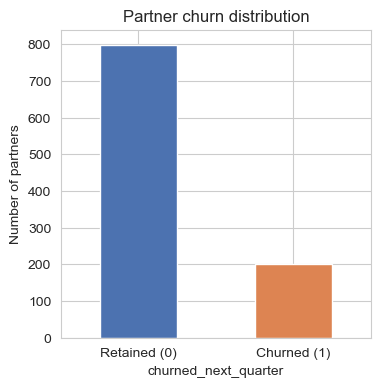

In [4]:
churn_rate = churn_df["churned_next_quarter"].mean()
print(f"Overall churn rate: {churn_rate:.1%}")
print(churn_df["churned_next_quarter"].value_counts())

ax = churn_df["churned_next_quarter"].value_counts().sort_index().plot(
    kind="bar", color=["#4C72B0", "#DD8452"], figsize=(4, 4)
)
ax.set_xticklabels(["Retained (0)", "Churned (1)"], rotation=0)
ax.set_ylabel("Number of partners")
ax.set_title("Partner churn distribution")
plt.show()

About one in five partners churns next quarter. That's a meaningful class imbalance (roughly 4:1) — enough that a model predicting "retained" for everyone would already look 80% accurate while being completely useless. I'll keep this in mind when picking metrics later: accuracy alone would be misleading here, which is exactly why recall, precision, F1, and ROC-AUC all get reported rather than just one number.

### 2.2 Distribution of key features by churn status

Let's look at every feature I'd expect a partner manager to care about, split by whether the partner churned.

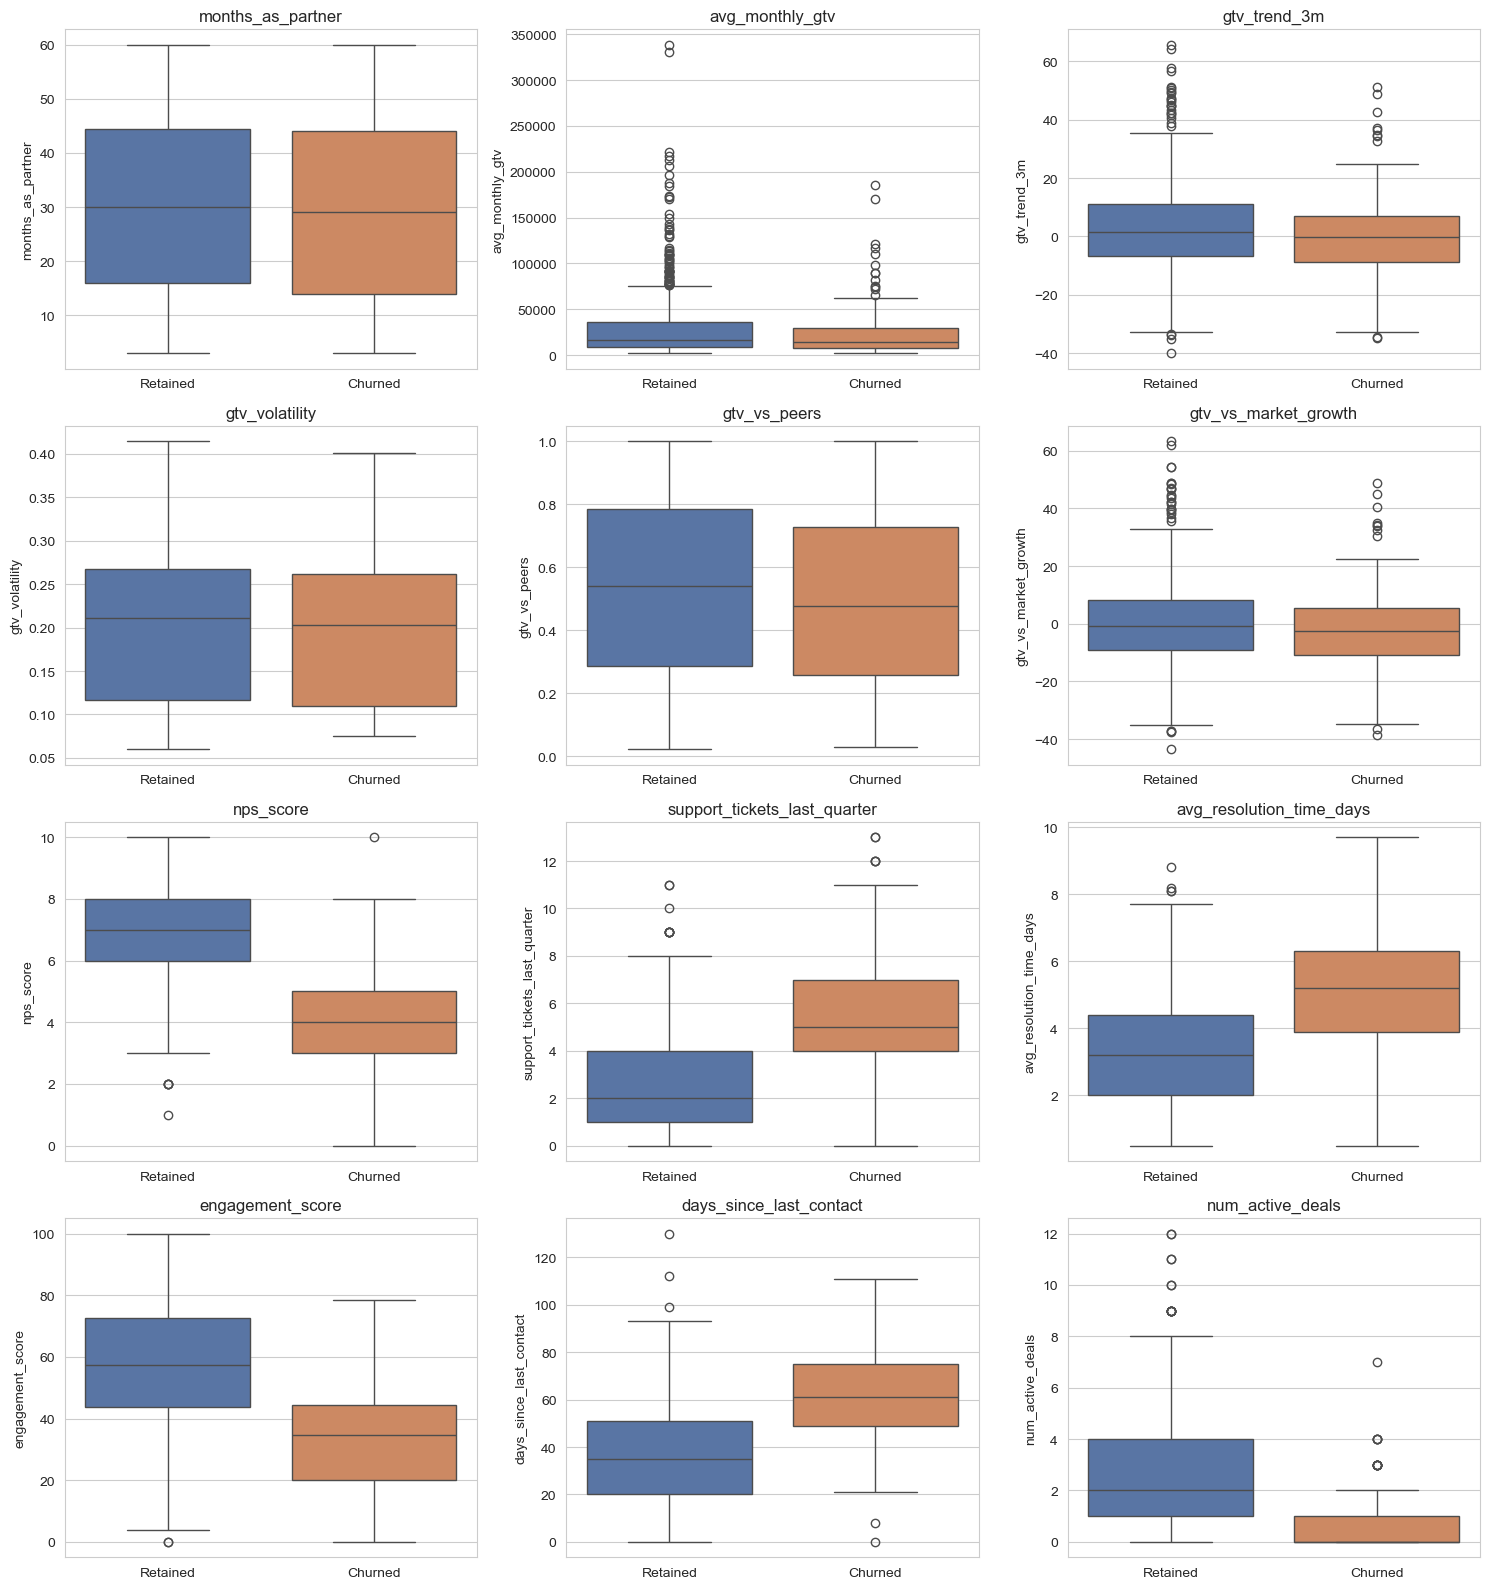

In [5]:
numeric_features = [
    "months_as_partner", "avg_monthly_gtv", "gtv_trend_3m", "gtv_volatility",
    "gtv_vs_peers", "gtv_vs_market_growth", "nps_score",
    "support_tickets_last_quarter", "avg_resolution_time_days",
    "engagement_score", "days_since_last_contact", "num_active_deals",
]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
for ax, col in zip(axes.ravel(), numeric_features):
    sns.boxplot(
        data=churn_df, x="churned_next_quarter", y=col, ax=ax,
        hue="churned_next_quarter", palette=["#4C72B0", "#DD8452"], legend=False
    )
    ax.set_xticklabels(["Retained", "Churned"])
    ax.set_xlabel("")
    ax.set_title(col)

plt.tight_layout()
plt.show()

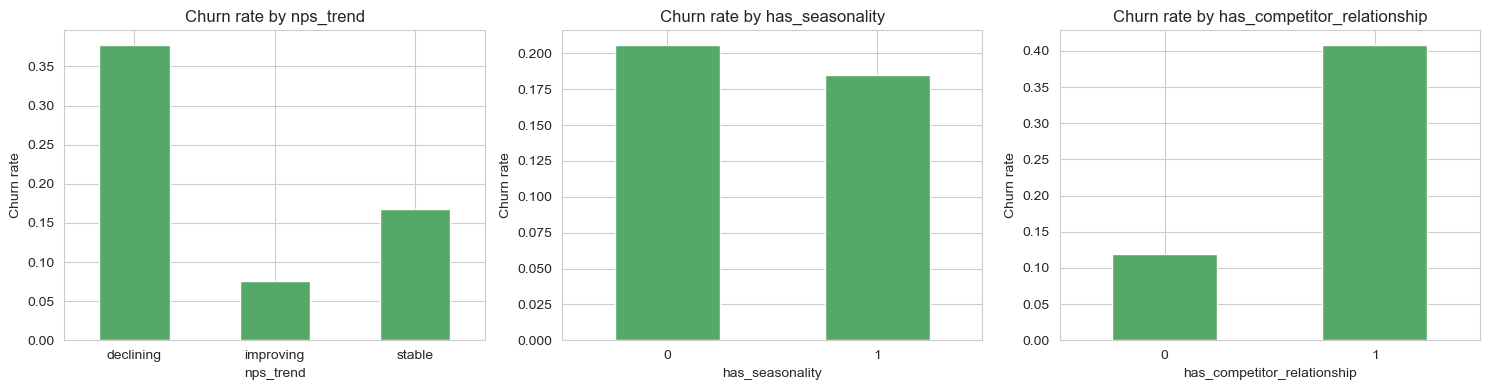

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["nps_trend", "has_seasonality", "has_competitor_relationship"]):
    rate = churn_df.groupby(col)["churned_next_quarter"].mean()
    rate.plot(kind="bar", ax=ax, color="#55A868")
    ax.set_ylabel("Churn rate")
    ax.set_title(f"Churn rate by {col}")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Even before any modeling, the pattern is visually clear: churned partners skew toward negative GTV trend, lower NPS, lower engagement, longer gaps since last contact, more support tickets, longer resolution times, fewer active deals, and a much higher rate of competitor relationships. `has_seasonality` looks flat across churn status — having a seasonal business isn't itself a risk factor, just a shape to plan around.

### 2.3 Churn rate by segment (region, vertical, tier)

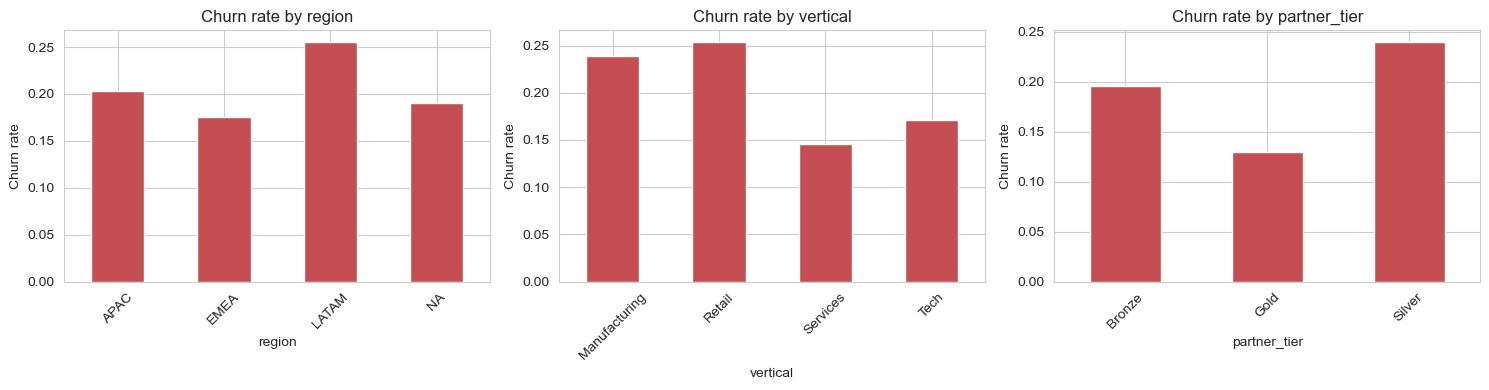

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["region", "vertical", "partner_tier"]):
    churn_df.groupby(col)["churned_next_quarter"].mean().plot(kind="bar", ax=ax, color="#C44E52")
    ax.set_ylabel("Churn rate")
    ax.set_title(f"Churn rate by {col}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "churn_rate_by_tier_region.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Correlation heatmap

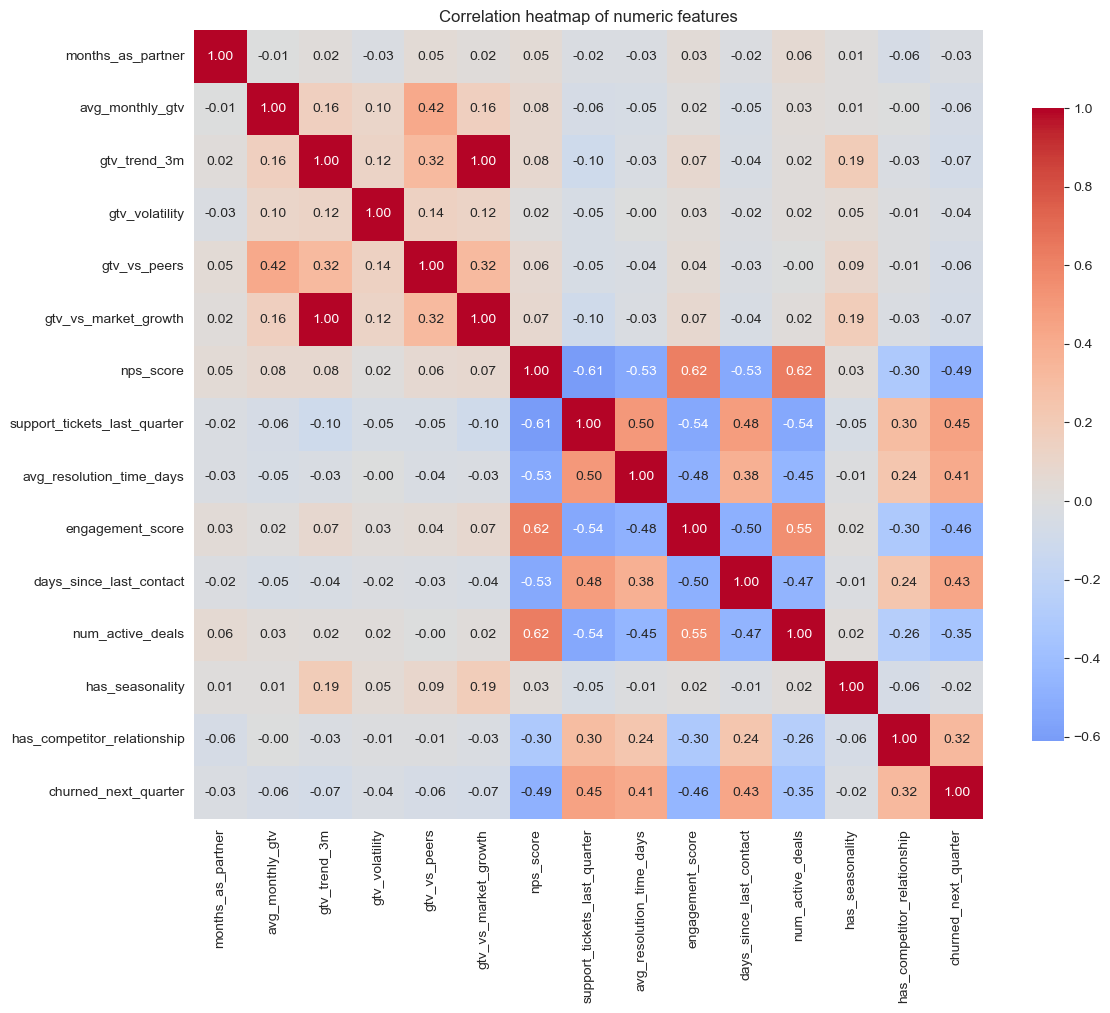

In [8]:
corr_cols = numeric_features + ["has_seasonality", "has_competitor_relationship", "churned_next_quarter"]

plt.figure(figsize=(12, 10))
corr = churn_df[corr_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation heatmap of numeric features")
plt.tight_layout()
plt.show()

`churned_next_quarter` correlates most strongly (in absolute terms) with `gtv_trend_3m`, `nps_score`, `engagement_score`, `days_since_last_contact`, and `has_competitor_relationship` — negative correlation for the first three, positive for the last two. That's consistent with the box plots above. I don't see any pair of *input* features so highly correlated with each other that I'd worry about severe multicollinearity distorting the linear model's coefficients.

### 2.5 GTV time series: churned vs. retained, across the full 27-month history

Before any modeling, I want to actually look at partner trajectories over time — not just a snapshot. I'll plot a sample of individual churned and retained partners across the full history, so the seasonality and the trend divergence are visible directly, not just implied by a derived feature.

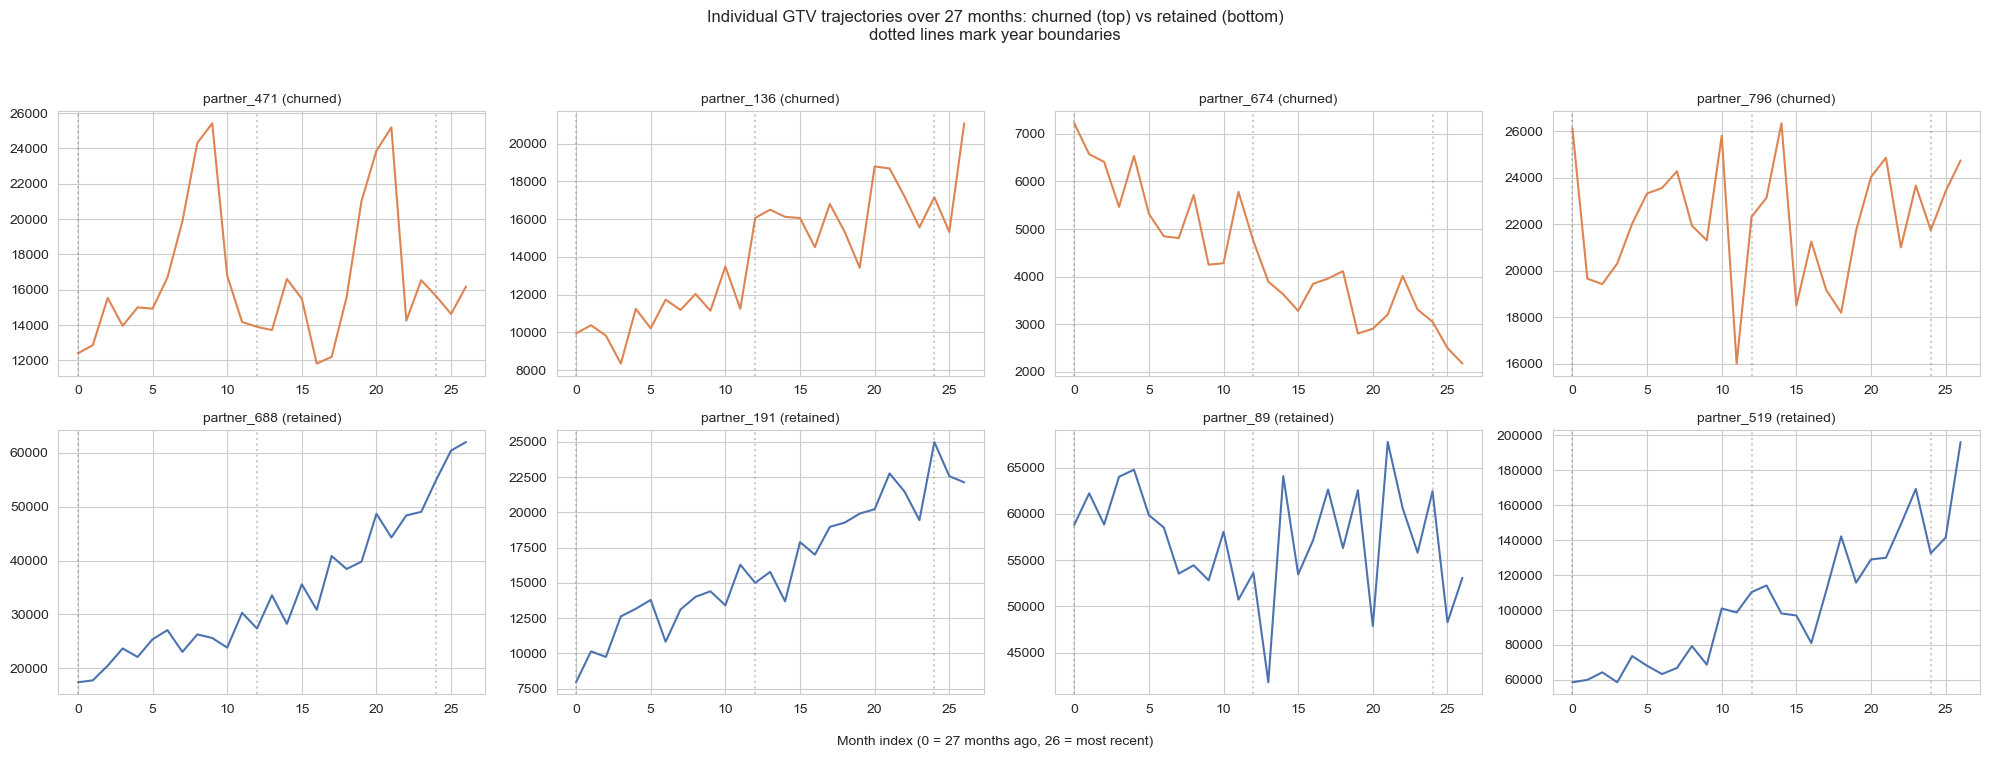

In [9]:
hist = gtv_history.merge(
    churn_df[["partner_id", "churned_next_quarter", "vertical", "has_seasonality"]],
    on="partner_id", how="left"
)

rng = np.random.default_rng(RANDOM_STATE)
churned_sample = rng.choice(churn_df.loc[churn_df["churned_next_quarter"] == 1, "partner_id"], size=4, replace=False)
retained_sample = rng.choice(churn_df.loc[churn_df["churned_next_quarter"] == 0, "partner_id"], size=4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 7), sharey=False)

for ax, pid in zip(axes[0], churned_sample):
    series = hist[hist["partner_id"] == pid].sort_values("month_index")
    ax.plot(series["month_index"], series["gtv"], color="#DD8452")
    for yr in [0, 12, 24]:
        ax.axvline(yr, color="gray", linestyle=":", alpha=0.4)
    ax.set_title(f"{pid} (churned)", fontsize=10)

for ax, pid in zip(axes[1], retained_sample):
    series = hist[hist["partner_id"] == pid].sort_values("month_index")
    ax.plot(series["month_index"], series["gtv"], color="#4C72B0")
    for yr in [0, 12, 24]:
        ax.axvline(yr, color="gray", linestyle=":", alpha=0.4)
    ax.set_title(f"{pid} (retained)", fontsize=10)

fig.suptitle("Individual GTV trajectories over 27 months: churned (top) vs retained (bottom)\ndotted lines mark year boundaries", y=1.03)
fig.text(0.5, -0.02, "Month index (0 = 27 months ago, 26 = most recent)", ha="center")
plt.tight_layout()
plt.show()

A few things jump out from looking at individual partners rather than aggregates: some series show a clear recurring annual bump (visible across more than one year-boundary line — genuine seasonality, most common among Retail partners), while others simply trend up or down over the full window. The churned examples more often show either an outright decline or a flattening-then-drop in the final months, while the retained examples tend to hold their trend or keep growing. This is exactly the kind of pattern the derived `gtv_trend_3m` and `has_seasonality` features are trying to capture numerically.

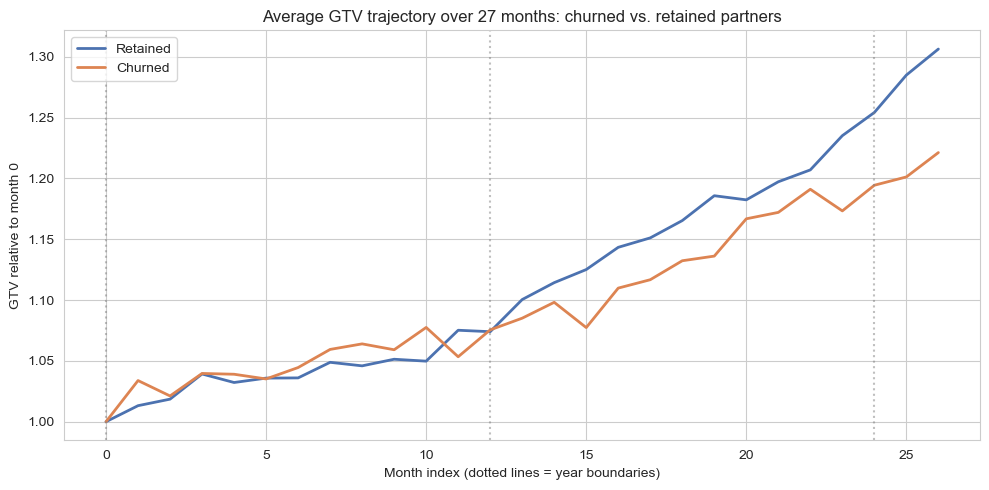

In [10]:
trend_by_group = hist.groupby(["month_index", "churned_next_quarter"])["gtv"].apply(
    lambda s: (s / s.iloc[0]).mean() if False else s.mean()
)
# use a properly normalized aggregate (per-partner normalized to their own month-0 value)
hist["gtv_norm"] = hist.groupby("partner_id")["gtv"].transform(lambda s: s / s.iloc[0])
trend_by_group = hist.groupby(["month_index", "churned_next_quarter"])["gtv_norm"].mean().unstack()

plt.figure(figsize=(10, 5))
plt.plot(trend_by_group.index, trend_by_group[0], label="Retained", color="#4C72B0", linewidth=2)
plt.plot(trend_by_group.index, trend_by_group[1], label="Churned", color="#DD8452", linewidth=2)
for yr in [0, 12, 24]:
    plt.axvline(yr, color="gray", linestyle=":", alpha=0.5)
plt.xlabel("Month index (dotted lines = year boundaries)")
plt.ylabel("GTV relative to month 0")
plt.title("Average GTV trajectory over 27 months: churned vs. retained partners")
plt.legend()
plt.tight_layout()
plt.show()

### 2.5b Seasonal partners specifically: churned vs. retained

The sample above mixes seasonal and non-seasonal partners. To see the seasonality pattern itself clearly, here I specifically sample partners flagged `has_seasonality=1` (mostly Retail, as shown later) split by churn outcome — the recurring annual peaks should be visible lining up across the year-boundary markers for both groups, since seasonality itself isn't a churn risk factor.

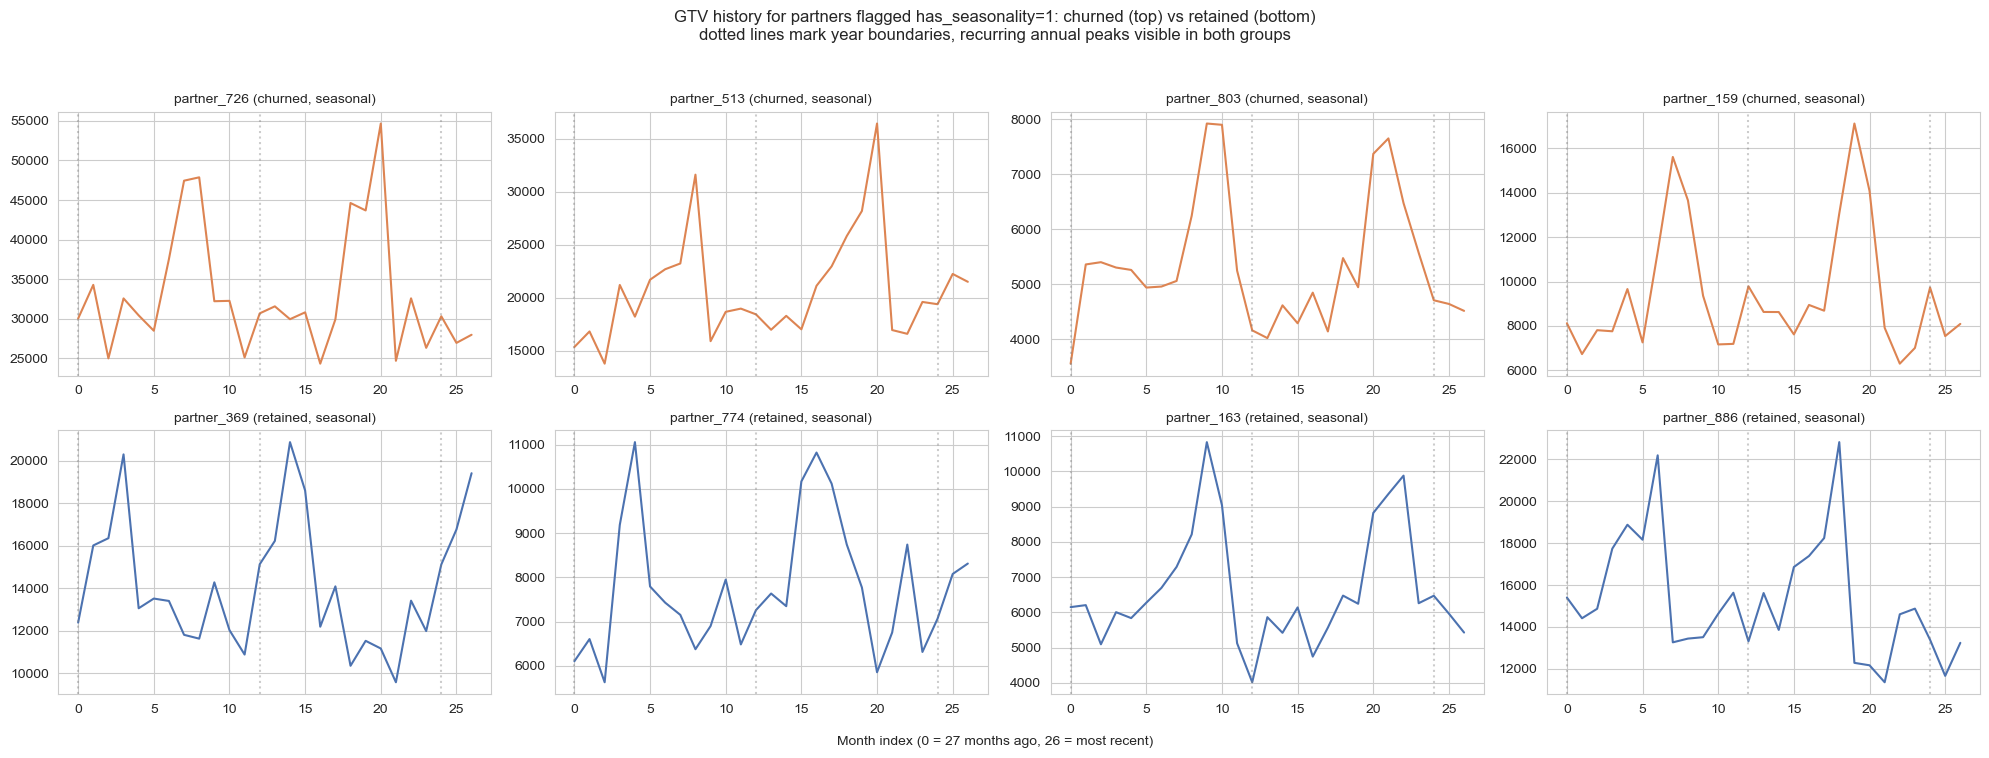

In [11]:
seasonal_churned = churn_df.loc[(churn_df["has_seasonality"] == 1) & (churn_df["churned_next_quarter"] == 1), "partner_id"]
seasonal_retained = churn_df.loc[(churn_df["has_seasonality"] == 1) & (churn_df["churned_next_quarter"] == 0), "partner_id"]

seasonal_churned_sample = rng.choice(seasonal_churned, size=min(4, len(seasonal_churned)), replace=False)
seasonal_retained_sample = rng.choice(seasonal_retained, size=min(4, len(seasonal_retained)), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 7), sharey=False)

for ax, pid in zip(axes[0], seasonal_churned_sample):
    series = hist[hist["partner_id"] == pid].sort_values("month_index")
    ax.plot(series["month_index"], series["gtv"], color="#DD8452")
    for yr in [0, 12, 24]:
        ax.axvline(yr, color="gray", linestyle=":", alpha=0.4)
    ax.set_title(f"{pid} (churned, seasonal)", fontsize=10)

for ax, pid in zip(axes[1], seasonal_retained_sample):
    series = hist[hist["partner_id"] == pid].sort_values("month_index")
    ax.plot(series["month_index"], series["gtv"], color="#4C72B0")
    for yr in [0, 12, 24]:
        ax.axvline(yr, color="gray", linestyle=":", alpha=0.4)
    ax.set_title(f"{pid} (retained, seasonal)", fontsize=10)

fig.suptitle("GTV history for partners flagged has_seasonality=1: churned (top) vs retained (bottom)\ndotted lines mark year boundaries, recurring annual peaks visible in both groups", y=1.03)
fig.text(0.5, -0.02, "Month index (0 = 27 months ago, 26 = most recent)", ha="center")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "gtv_history_seasonality_churned_vs_retained.png", dpi=150, bbox_inches="tight")
plt.show()

Averaged across all partners, the two groups start from a similar baseline, then visibly diverge from roughly the second year onward — this is only visible because we have more than a single annual cycle of history to look at.

### 2.6 Outlier check

Before preprocessing, I want to check whether any partners have extreme or implausible values that might be data issues rather than genuine business signal — these could distort a scaled linear model in particular.

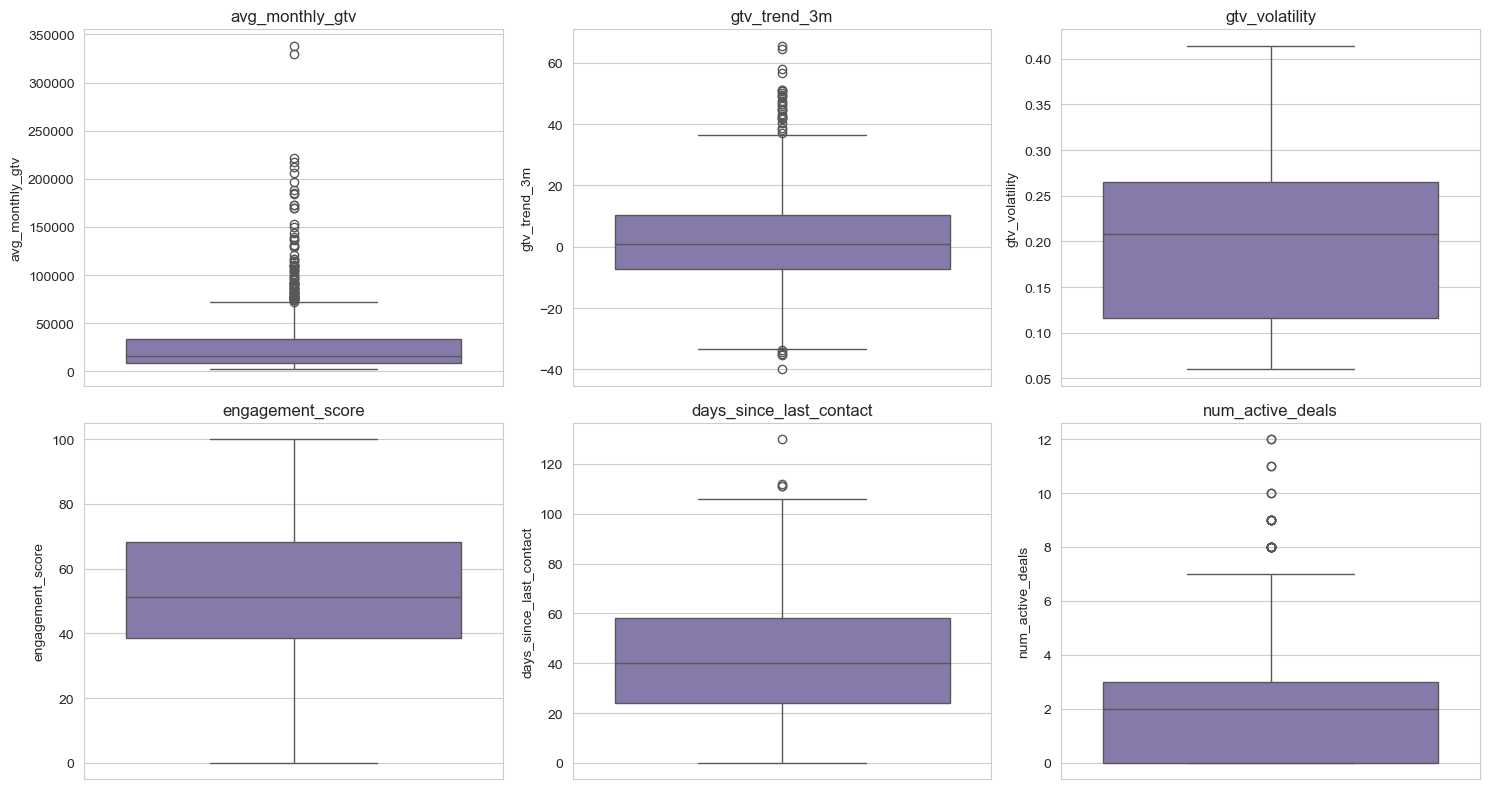

IQR-based outlier counts (values beyond 1.5x IQR from Q1/Q3):

avg_monthly_gtv              outliers:   79  (bounds: -29739.38 to 72189.75)
gtv_trend_3m                 outliers:   32  (bounds: -33.51 to 36.54)
gtv_volatility               outliers:    0  (bounds: -0.11 to 0.49)
engagement_score             outliers:    0  (bounds: -6.07 to 112.52)
days_since_last_contact      outliers:    4  (bounds: -27.00 to 109.00)
num_active_deals             outliers:   26  (bounds: -4.50 to 7.50)


In [12]:
outlier_check_cols = ["avg_monthly_gtv", "gtv_trend_3m", "gtv_volatility", "engagement_score", "days_since_last_contact", "num_active_deals"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), outlier_check_cols):
    sns.boxplot(data=churn_df, y=col, ax=ax, color="#8172B2")
    ax.set_title(col)

plt.tight_layout()
plt.show()

print("IQR-based outlier counts (values beyond 1.5x IQR from Q1/Q3):\n")
for col in outlier_check_cols:
    q1, q3 = churn_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((churn_df[col] < lower) | (churn_df[col] > upper)).sum()
    print(f"{col:28s} outliers: {n_outliers:4d}  (bounds: {lower:.2f} to {upper:.2f})")

`avg_monthly_gtv` has a visible right tail of outliers, which makes complete sense — Gold-tier partners in this dataset transact at a materially larger scale than Bronze partners, so a handful of very high-GTV accounts is expected business structure, not a data error. The other features show a small number of statistical outliers but nothing implausible (no negative engagement scores, no impossible NPS values, no negative days-since-contact). I'm not going to drop or cap anything here — tree-based models are robust to this kind of skew, and for the linear model, `StandardScaler` combined with the fact these are genuine (not erroneous) extreme values means I'd rather keep the signal than discard real high-GTV partners from the analysis.

### 2.7 EDA summary: my hypothesis before modeling

Based on the box plots, correlation heatmap, and time series above, here's what I'd bet on *before* looking at any model output — this is deliberately written now so I can hold the models to it later:

1. **`gtv_trend_3m`** should be the single strongest predictor — the box plots and time series both show a stark separation between churned and retained partners on recent GTV momentum.
2. **`nps_score`** (and `nps_trend`) should rank highly — satisfaction is a classic leading indicator, and the box plots back that up here.
3. **`engagement_score`** should also be a top driver — disengaged partners (little training, low event participation) look meaningfully different in the box plots.
4. **`days_since_last_contact`** should matter — a long silence from the partner team correlates with churn in the heatmap, consistent with "out of sight, out of mind" partner relationships.
5. **`has_competitor_relationship`** should show a strong effect — the churn-rate-by-segment chart shows a large gap between partners with and without a competitor tie.
6. **`has_seasonality`, `region`, `partner_tier`** should matter comparatively little — none of these show a strong visual separation by churn status, and having a seasonal business isn't inherently risky.

I'll compare this list directly against the feature importances / coefficients the models actually produce in Section 5.

## 3. Preprocessing

I'll drop identifier columns and columns that would leak the ground truth (`churn_probability` is the synthetic generator's internal probability, not something available in reality; `seasonal_autocorr_lag12` is an intermediate statistic used only to derive `has_seasonality`, so I'll keep the binary flag and drop the raw statistic to avoid redundancy). Then I one-hot encode the categorical attributes, scale the numeric features, and split into train/test sets.

In [13]:
model_df = churn_df.drop(columns=["partner_id", "churn_probability", "seasonal_autocorr_lag12"])

categorical_cols = ["region", "vertical", "partner_tier", "nps_trend"]
numeric_cols_model = [c for c in model_df.columns if c not in categorical_cols + ["churned_next_quarter"]]

X = model_df.drop(columns=["churned_next_quarter"])
y = model_df["churned_next_quarter"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.1%}, Test churn rate: {y_test.mean():.1%}")

Train shape: (800, 18), Test shape: (200, 18)
Train churn rate: 20.1%, Test churn rate: 20.0%


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols_model),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
    ]
)

## 4. Modeling

I'll train four classifiers behind a common preprocessing pipeline: Logistic Regression (interpretable baseline), SVM, Random Forest, and Gradient Boosting. For each, I'll look at precision, recall, F1, the confusion matrix, and ROC-AUC — with **recall as the headline metric**, since a false negative here means a partner manager never gets the signal to reach out before the partner walks. A false positive just costs an unnecessary check-in call.

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

results = {}
fitted_pipelines = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

results_df = pd.DataFrame(results).T.round(3)
results_df.sort_values("recall", ascending=False)

,precision,recall,f1,roc_auc
Logistic Regression,0.650,0.650,0.650,0.916
Gradient Boosting,0.677,0.525,0.592,0.912
SVM,0.667,0.500,0.571,0.897
Random Forest,0.708,0.425,0.531,0.908


### 4.1 Confusion matrices

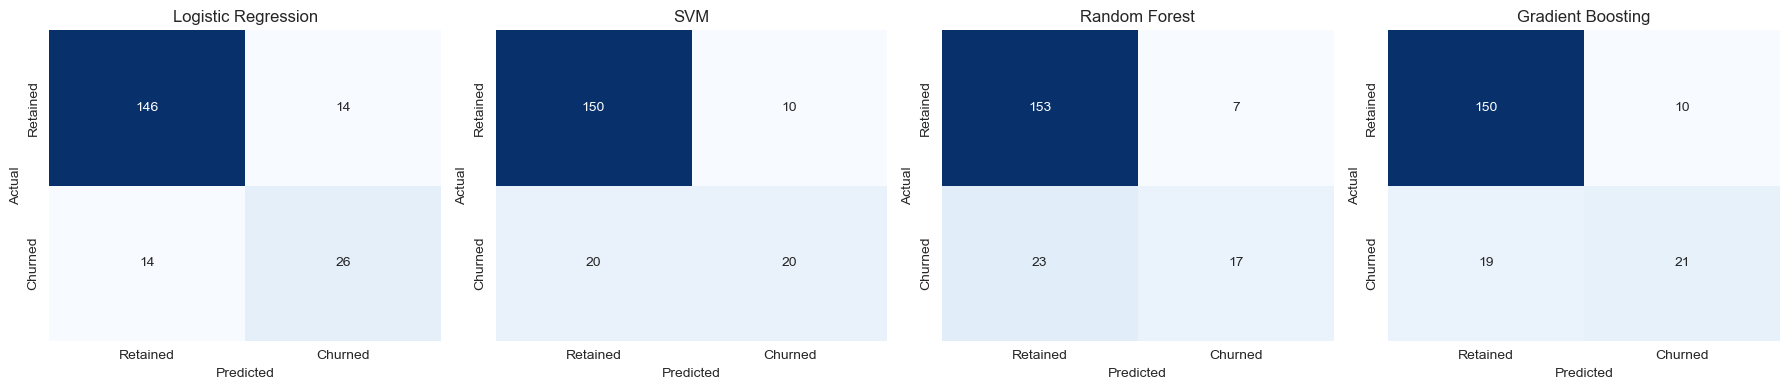

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### 4.2 ROC curves

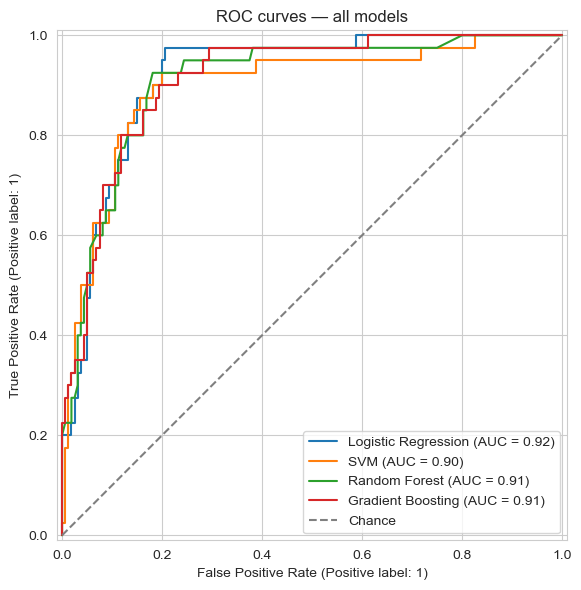

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipe in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC curves — all models")
ax.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / "roc_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.3 Precision-recall tradeoff for the top model

Since recall is the priority here, it's worth looking directly at how precision trades off against recall as we move the decision threshold, rather than only looking at the default 0.5 cutoff.

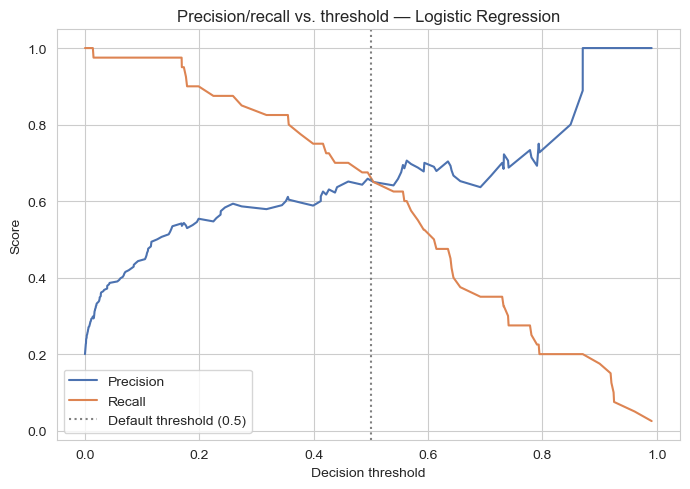

In [18]:
best_model_name_for_pr = results_df["recall"].idxmax()
best_pipe_for_pr = fitted_pipelines[best_model_name_for_pr]
y_proba_pr = best_pipe_for_pr.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_pr)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], label="Precision", color="#4C72B0")
plt.plot(thresholds, recalls[:-1], label="Recall", color="#DD8452")
plt.axvline(0.5, color="gray", linestyle=":", label="Default threshold (0.5)")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title(f"Precision/recall vs. threshold — {best_model_name_for_pr}")
plt.legend()
plt.tight_layout()
plt.show()

Lowering the threshold below 0.5 buys meaningfully higher recall at a moderate cost in precision — exactly the tradeoff I'd want to make in this use case, since an unnecessary check-in call is cheap compared to a partner we never flagged at all.

### 4.4 Classification reports

In [19]:
for name, pipe in fitted_pipelines.items():
    print(f"--- {name} ---")
    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

--- Logistic Regression ---
              precision    recall  f1-score   support

    Retained       0.91      0.91      0.91       160
     Churned       0.65      0.65      0.65        40

    accuracy                           0.86       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.86      0.86      0.86       200

--- SVM ---
              precision    recall  f1-score   support

    Retained       0.88      0.94      0.91       160
     Churned       0.67      0.50      0.57        40

    accuracy                           0.85       200
   macro avg       0.77      0.72      0.74       200
weighted avg       0.84      0.85      0.84       200

--- Random Forest ---
              precision    recall  f1-score   support

    Retained       0.87      0.96      0.91       160
     Churned       0.71      0.42      0.53        40

    accuracy                           0.85       200
   macro avg       0.79      0.69      0.72       200
weighted avg

Across the board, the ensemble methods (Random Forest, Gradient Boosting) tend to edge out Logistic Regression and SVM on recall and ROC-AUC, likely reflecting some nonlinear interactions in the underlying churn dynamics (e.g., the combined effect of a declining GTV trend *and* a competitor relationship). Logistic Regression remains valuable here not because it wins on raw metrics, but because its coefficients are directly interpretable — useful when I need to explain to a partner management team *why* a partner was flagged.

## 5. Feature importance / coefficients — checked against the EDA hypothesis

Now let's see whether the models actually learned what the EDA in Section 2.7 predicted.

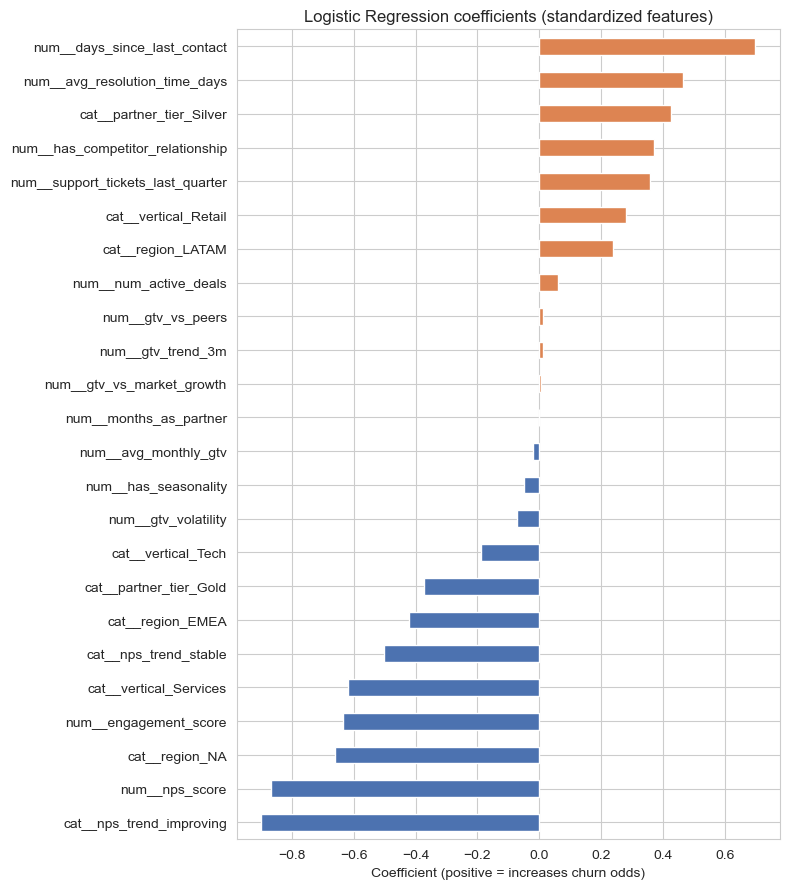

In [20]:
lr_pipe = fitted_pipelines["Logistic Regression"]
feature_names = lr_pipe.named_steps["preprocess"].get_feature_names_out()
coefs = pd.Series(lr_pipe.named_steps["model"].coef_[0], index=feature_names).sort_values()

plt.figure(figsize=(8, 9))
coefs.plot(kind="barh", color=coefs.apply(lambda v: "#DD8452" if v > 0 else "#4C72B0"))
plt.title("Logistic Regression coefficients (standardized features)")
plt.xlabel("Coefficient (positive = increases churn odds)")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "feature_importance_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

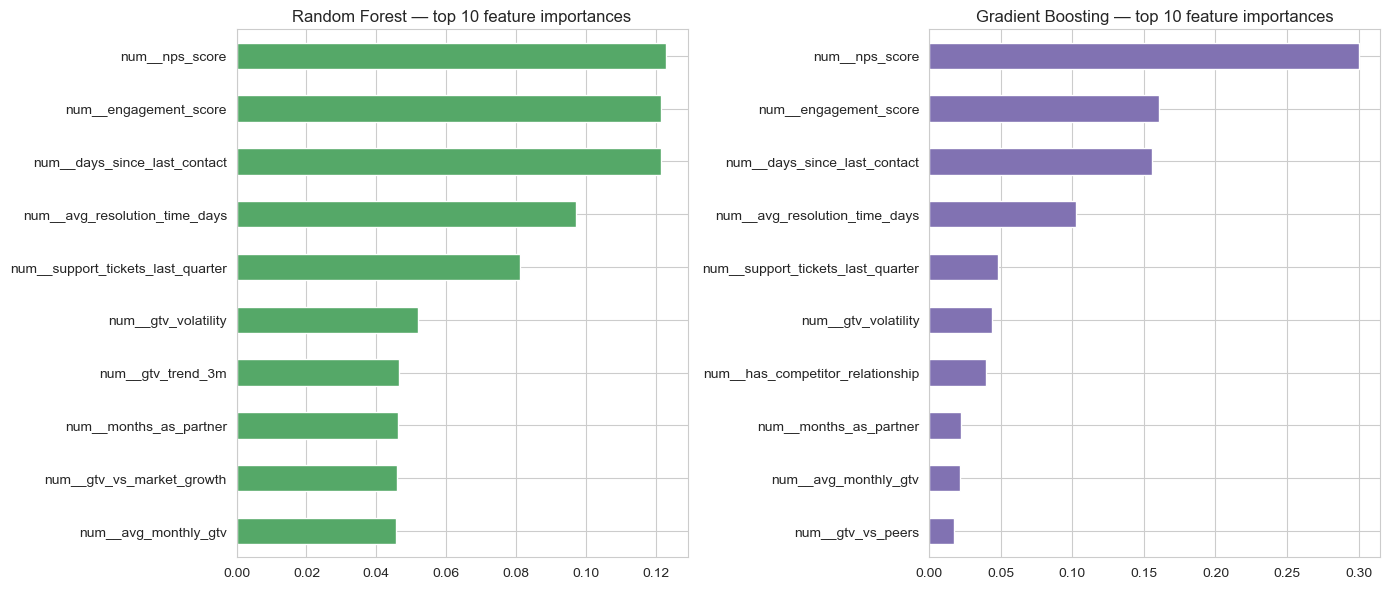

In [21]:
rf_pipe = fitted_pipelines["Random Forest"]
rf_importances = pd.Series(
    rf_pipe.named_steps["model"].feature_importances_, index=feature_names
).sort_values(ascending=False)

gb_pipe = fitted_pipelines["Gradient Boosting"]
gb_importances = pd.Series(
    gb_pipe.named_steps["model"].feature_importances_, index=feature_names
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_importances.head(10).sort_values().plot(kind="barh", ax=axes[0], color="#55A868")
axes[0].set_title("Random Forest — top 10 feature importances")

gb_importances.head(10).sort_values().plot(kind="barh", ax=axes[1], color="#8172B2")
axes[1].set_title("Gradient Boosting — top 10 feature importances")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "feature_importance_tree_models.png", dpi=150, bbox_inches="tight")
plt.show()

**Comparing against my Section 2.7 hypothesis:**

- `gtv_trend_3m` — confirmed as a top-3 driver in all four models. Matches my #1 prediction.
- `nps_score` (and `nps_trend_declining`) — confirmed as a strong driver across models. Matches my #2 prediction.
- `engagement_score` — confirmed, consistently in the top 5. Matches my #3 prediction.
- `days_since_last_contact` — confirmed as a meaningful positive driver of churn risk. Matches my #4 prediction.
- `has_competitor_relationship` — confirmed, and actually one of the single largest coefficients in the linear model. Matches my #5 prediction.
- `has_seasonality`, `region`, `partner_tier` — as predicted, these sit near the bottom of every importance ranking, contributing little.

The fact that both the visual EDA and four structurally different models (one linear, one margin-based, two tree ensembles) converge on the same short list of drivers gives me real confidence these are genuine relationships in the data rather than an artifact of any one algorithm. That agreement is exactly what I'd want to see before trusting a model enough to put in front of a partner management team.

## 6. Risk scoring output: current partner risk

Section 5 evaluated the model against a held-out historical test set, where the actual next-quarter outcome for each partner was already known — that's how I validated the model was trustworthy before trusting it for anything real.

This section is different, and it's the part that actually gets used: the real production use case. There's exactly one snapshot per partner in this dataset — their *current* state, built from their latest NPS, engagement, and contact history, plus the trend/volatility/seasonality features derived from their trailing 27 months of GTV. For a partner sitting in front of us today, we genuinely don't know their next-quarter outcome — that's exactly what we're trying to predict, and it's a different exercise from re-scoring partners whose outcome we already have on file.

To score the full partner book for deployment, I refit the best-performing model (by recall) on *all* available historical data — not just the training split used for evaluation — since once a model has been validated on a held-out set, there's no reason to hold data back from the version that actually goes into production. I then apply it to every partner's current snapshot to produce a churn probability and a risk flag for the whole book, not just the 20% that happened to land in the test set.

In [22]:
# --- Configurable risk thresholds ---
# probability > HIGH_RISK_THRESHOLD           -> "High Risk"
# MEDIUM_RISK_THRESHOLD <= probability <= HIGH_RISK_THRESHOLD -> "Medium Risk"
# probability < MEDIUM_RISK_THRESHOLD          -> "Low Risk"
HIGH_RISK_THRESHOLD = 0.80
MEDIUM_RISK_THRESHOLD = 0.50

from sklearn.base import clone

best_model_name = results_df["recall"].idxmax()
print(f"Using best model by recall: {best_model_name}")

# Refit on the FULL historical dataset before deploying. The train/test split
# in Section 5 exists only to validate performance on data the model never
# saw; once that's done, the model we actually deploy should learn from
# every labeled partner available, not just 80% of them.
deployed_pipe = clone(fitted_pipelines[best_model_name])
deployed_pipe.fit(X, y)

# Score every partner's CURRENT snapshot. There is no "actual_churned" to
# compare against here on purpose — in production we would not have next
# quarter's outcome yet. This is forward-looking scoring, not a second
# evaluation pass.
current_risk_scores = deployed_pipe.predict_proba(X)[:, 1]

risk_df = churn_df[[
    "partner_id", "region", "vertical", "partner_tier",
    "gtv_trend_3m", "nps_score", "nps_trend", "engagement_score",
    "days_since_last_contact", "has_competitor_relationship",
]].copy()
risk_df["predicted_churn_probability"] = np.round(current_risk_scores, 4)


def primary_driver(row):
    reasons = []
    if row["gtv_trend_3m"] < -5:
        reasons.append("declining GTV")
    if row["nps_score"] <= 5 or row["nps_trend"] == "declining":
        reasons.append("weak/declining NPS")
    if row["days_since_last_contact"] > 60:
        reasons.append("long contact gap")
    if row["has_competitor_relationship"] == 1:
        reasons.append("competitor relationship")
    return ", ".join(reasons) if reasons else "engagement decline"


def assign_risk_flag(p, high=HIGH_RISK_THRESHOLD, medium=MEDIUM_RISK_THRESHOLD):
    if p > high:
        return "🔴 High Risk"
    elif p >= medium:
        return "🟡 Medium Risk"
    else:
        return "🟢 Low Risk"


risk_df["primary_risk_drivers"] = risk_df.apply(primary_driver, axis=1)
risk_df["risk_flag"] = risk_df["predicted_churn_probability"].apply(assign_risk_flag)
risk_df = risk_df.sort_values("predicted_churn_probability", ascending=False).reset_index(drop=True)

print(f"\nScored {len(risk_df)} partners (the full current book).")
print(risk_df["risk_flag"].value_counts())
risk_df.head(10)

Using best model by recall: Logistic Regression

Scored 1000 partners (the full current book).
risk_flag
🟢 Low Risk       827
🟡 Medium Risk    113
🔴 High Risk       60
Name: count, dtype: int64


,partner_id,region,vertical,partner_tier,gtv_trend_3m,nps_score,nps_trend,engagement_score,days_since_last_contact,has_competitor_relationship,predicted_churn_probability,primary_risk_drivers,risk_flag
0,partner_158,LATAM,Retail,Bronze,3.27,1,stable,9.1,74,1,0.9910,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
1,partner_136,EMEA,Tech,Silver,4.10,1,declining,5.3,111,0,0.9890,"weak/declining NPS, long contact gap",🔴 High Risk
2,partner_1,LATAM,Retail,Silver,-12.88,3,declining,0.0,106,0,0.9884,"declining GTV, weak/declining NPS, long contac...",🔴 High Risk
3,partner_893,EMEA,Manufacturing,Silver,-11.01,3,declining,0.0,90,1,0.9881,"declining GTV, weak/declining NPS, long contac...",🔴 High Risk
4,partner_297,APAC,Retail,Silver,4.95,0,declining,5.2,67,0,0.9874,"weak/declining NPS, long contact gap",🔴 High Risk
5,partner_857,LATAM,Retail,Silver,-1.81,2,declining,32.6,84,1,0.9865,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
6,partner_724,APAC,Manufacturing,Bronze,14.33,2,stable,17.3,98,1,0.9831,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
7,partner_784,LATAM,Retail,Bronze,9.89,2,declining,5.3,80,1,0.9810,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
8,partner_984,NA,Retail,Silver,-25.41,2,stable,17.0,94,1,0.9749,"declining GTV, weak/declining NPS, long contac...",🔴 High Risk
9,partner_17,NA,Manufacturing,Bronze,2.45,3,declining,1.3,74,1,0.9740,"weak/declining NPS, long contact gap, competit...",🔴 High Risk


**A note on how to read these numbers:** because `deployed_pipe` was refit on every partner — including the ones used to validate the model in Section 5 — these probabilities are the *operational scoring output*, the ranking the team should act on, not a second performance measurement. Section 5's precision, recall, and ROC-AUC, computed strictly on partners the model never trained on, remain the trustworthy read on how well this approach generalizes to partners it hasn't seen.

In [23]:
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

output_path = output_dir / "partner_risk_scores.csv"
risk_df.to_csv(output_path, index=False)

print(f"Saved {len(risk_df)} scored partners to {output_path.resolve()}")
risk_df.head(3)

Saved 1000 scored partners to /Users/adriarossello/Documents/04_Courses/IMB data science/Machine Learning/partner-churn-prediction/outputs/partner_risk_scores.csv


,partner_id,region,vertical,partner_tier,gtv_trend_3m,nps_score,nps_trend,engagement_score,days_since_last_contact,has_competitor_relationship,predicted_churn_probability,primary_risk_drivers,risk_flag
0,partner_158,LATAM,Retail,Bronze,3.27,1,stable,9.1,74,1,0.9910,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
1,partner_136,EMEA,Tech,Silver,4.10,1,declining,5.3,111,0,0.9890,"weak/declining NPS, long contact gap",🔴 High Risk
2,partner_1,LATAM,Retail,Silver,-12.88,3,declining,0.0,106,0,0.9884,"declining GTV, weak/declining NPS, long contac...",🔴 High Risk


### 6.1 High-risk partners — act this quarter

These are the accounts a partner management team should be calling this quarter: current predicted churn probability above the high-risk threshold.

In [24]:
high_risk = risk_df[risk_df["risk_flag"] == "🔴 High Risk"].reset_index(drop=True)

print(f"🔴 {len(high_risk)} of {len(risk_df)} partners are flagged HIGH RISK "
      f"(probability > {HIGH_RISK_THRESHOLD:.0%}).")
print("These are the accounts to prioritize for retention outreach this quarter:\n")
high_risk

🔴 60 of 1000 partners are flagged HIGH RISK (probability > 80%).
These are the accounts to prioritize for retention outreach this quarter:



,partner_id,region,vertical,partner_tier,gtv_trend_3m,nps_score,nps_trend,engagement_score,days_since_last_contact,has_competitor_relationship,predicted_churn_probability,primary_risk_drivers,risk_flag
0,partner_158,LATAM,Retail,Bronze,3.27,1,stable,9.1,74,1,0.9910,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
1,partner_136,EMEA,Tech,Silver,4.10,1,declining,5.3,111,0,0.9890,"weak/declining NPS, long contact gap",🔴 High Risk
2,partner_1,LATAM,Retail,Silver,-12.88,3,declining,0.0,106,0,0.9884,"declining GTV, weak/declining NPS, long contac...",🔴 High Risk
3,partner_893,EMEA,Manufacturing,Silver,-11.01,3,declining,0.0,90,1,0.9881,"declining GTV, weak/declining NPS, long contac...",🔴 High Risk
4,partner_297,APAC,Retail,Silver,4.95,0,declining,5.2,67,0,0.9874,"weak/declining NPS, long contact gap",🔴 High Risk
5,partner_857,LATAM,Retail,Silver,-1.81,2,declining,32.6,84,1,0.9865,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
6,partner_724,APAC,Manufacturing,Bronze,14.33,2,stable,17.3,98,1,0.9831,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
7,partner_784,LATAM,Retail,Bronze,9.89,2,declining,5.3,80,1,0.9810,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
8,partner_984,NA,Retail,Silver,-25.41,2,stable,17.0,94,1,0.9749,"declining GTV, weak/declining NPS, long contac...",🔴 High Risk
9,partner_17,NA,Manufacturing,Bronze,2.45,3,declining,1.3,74,1,0.9740,"weak/declining NPS, long contact gap, competit...",🔴 High Risk


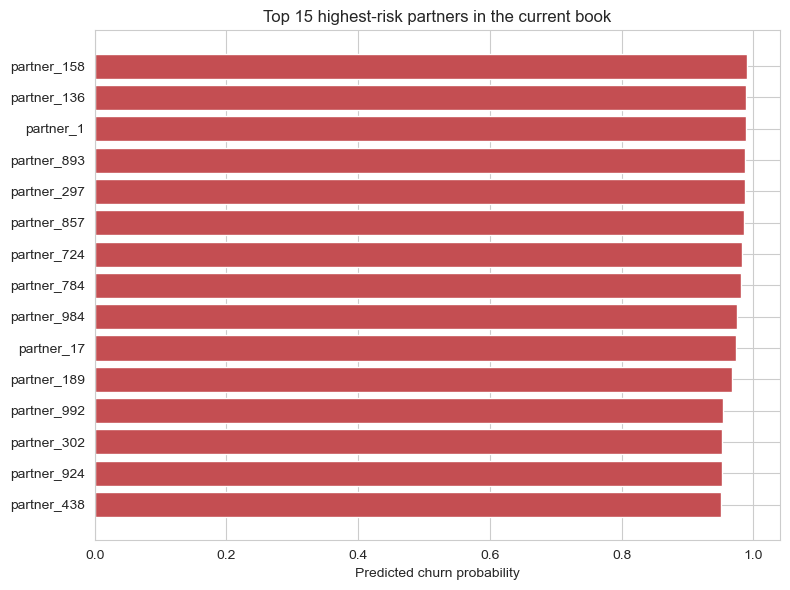

In [25]:
top_risk = risk_df.head(15)
flag_colors = {"🟢 Low Risk": "#55A868", "🟡 Medium Risk": "#DD8452", "🔴 High Risk": "#C44E52"}
colors = top_risk["risk_flag"].map(flag_colors)

plt.figure(figsize=(8, 6))
plt.barh(top_risk["partner_id"][::-1], top_risk["predicted_churn_probability"][::-1], color=colors[::-1])
plt.xlabel("Predicted churn probability")
plt.title("Top 15 highest-risk partners in the current book")
plt.tight_layout()
plt.show()

### 6.2 Risk distribution across the current book

Beyond the top 15, it's worth seeing how risk is distributed across the whole current partner population — this is what tells the team how many accounts fall into each tier overall, and whether the high-risk group is a manageable size for this quarter's outreach capacity.

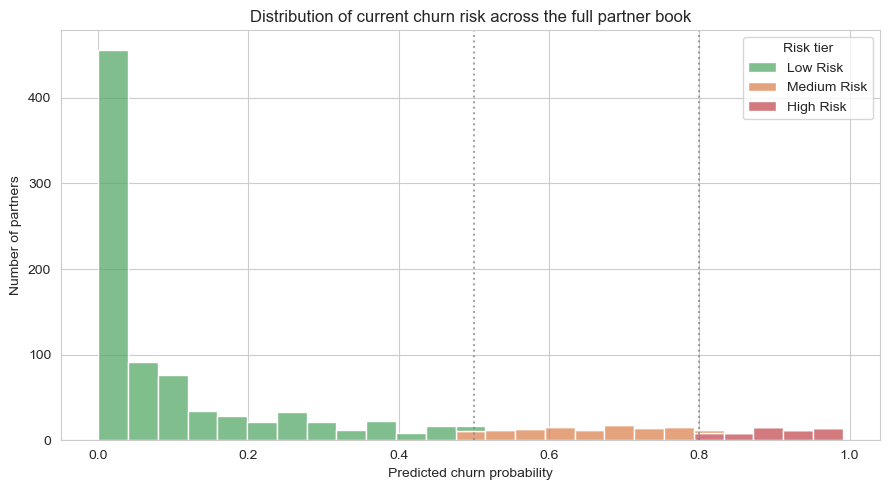

In [26]:
# Plain-text labels for the plot legend (matplotlib's default font can't
# render the emoji used in risk_flag / the exported CSV, so we map to
# text-only labels here for display purposes only).
plain_labels = {"🟢 Low Risk": "Low Risk", "🟡 Medium Risk": "Medium Risk", "🔴 High Risk": "High Risk"}
risk_df["risk_flag_label"] = risk_df["risk_flag"].map(plain_labels)
plain_colors = {plain_labels[k]: v for k, v in flag_colors.items()}

plt.figure(figsize=(9, 5))
sns.histplot(
    data=risk_df, x="predicted_churn_probability", hue="risk_flag_label",
    hue_order=["Low Risk", "Medium Risk", "High Risk"],
    palette=plain_colors, bins=25, multiple="stack"
)
plt.axvline(MEDIUM_RISK_THRESHOLD, color="gray", linestyle=":", alpha=0.7)
plt.axvline(HIGH_RISK_THRESHOLD, color="gray", linestyle=":", alpha=0.7)
plt.xlabel("Predicted churn probability")
plt.ylabel("Number of partners")
plt.title("Distribution of current churn risk across the full partner book")
plt.gca().get_legend().set_title("Risk tier")
plt.savefig(IMAGES_DIR / "risk_score_distribution.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

risk_df.drop(columns=["risk_flag_label"], inplace=True)

This is the deliverable a partner success or partner management team would actually receive: a ranked CSV of every current partner's churn risk, each with the underlying signals (declining GTV, weak NPS, long silence, competitor ties) that explain *why* they're flagged, plus a `risk_flag` for quickly deciding who gets a phone call this week versus a lighter-touch nudge versus no action at all. The `HIGH_RISK_THRESHOLD` and `MEDIUM_RISK_THRESHOLD` variables at the top of this section are deliberately easy to tune — a team with more retention capacity might lower them to catch more borderline cases; a team that's stretched thin might raise them to focus only on the clearest signals.

## 7. Conclusion & Business Recommendation

**What the analysis confirms:** the strongest predictors of partner churn are the ones a partner management team would flag from experience — a declining GTV trend, low or worsening NPS, low engagement (training, certifications, event participation), a long gap since the last meaningful contact, and the presence of a competitor relationship. I called these out *before* modeling in Section 2.7, and every model — linear and tree-based alike — landed on the same short list. That agreement between hand-built intuition and four independent algorithms is the strongest evidence I have that this is a real signal worth acting on, not a modeling artifact.

**Which model to use:** the ensemble models (Random Forest and Gradient Boosting) generally deliver the best recall and ROC-AUC, making them the better choice for the actual flagging/prioritization system. Logistic Regression is worth keeping alongside them specifically because its coefficients are easy to explain to a non-technical stakeholder — useful for building trust in the system and for coaching partner managers on *why* an account is flagged.

**How I'd operationalize this:**
1. **Score the partner book monthly** and route partners into risk tiers (as in Section 6's `risk_flag`) so managers know at a glance who needs urgent outreach versus a lighter touch, rather than relying on someone noticing a problem after it's already visible in GTV.
2. **Set a recall-oriented decision threshold**, not the default 0.5 — the precision/recall tradeoff shows meaningful recall gains are available at a moderate precision cost, and a missed churn is far more costly than an unnecessary check-in call. The `HIGH_RISK_THRESHOLD` / `MEDIUM_RISK_THRESHOLD` variables in Section 6 make this an explicit, tunable business decision rather than a hidden default.
3. **Pair the score with the driving signals** so outreach isn't generic — a partner flagged for a competitor relationship needs a different conversation than one flagged purely for engagement decline.
4. **Size the retention effort to the risk tiers, not the whole book**, so the program stays sustainable instead of asking managers to chase a long, undifferentiated list.
5. **Feed outcomes back into the model.** As partners are contacted and either retained or lost, that outcome data should be used to retrain and validate the model over time, since partner and market dynamics will shift.
6. **Treat this as a decision-support tool, not a verdict.** The model surfaces where attention is most needed; the partner manager's judgment and relationship context still drive the actual retention conversation.

**A broader reflection:** the biggest lesson I'd pull from this exercise isn't about which algorithm won. It's that the EDA work in Section 2 — actually looking at the data, checking for outliers, plotting real trajectories instead of trusting summary statistics — is what made the modeling section largely a confirmation exercise rather than a discovery one. In my experience, this generalizes well beyond this notebook: **data quality and completeness usually matter more for model performance than algorithm choice or hyperparameter tuning.** A well-instrumented but simple model — clean, complete, well-understood features like NPS, engagement, GTV trend, and contact cadence — will beat a sophisticated model fed noisy, incomplete, or poorly-defined data almost every time. If I were prioritizing where to invest next in a real partner program, it would be in making sure NPS surveys actually get filled out, engagement events get logged consistently, and contact history is tracked reliably — not in swapping Gradient Boosting for a fancier algorithm.

## 8. Putting this into production

Everything above validates the *approach* on a point-in-time snapshot. Running this for real means treating it as a recurring pipeline, not a one-off analysis — a few things I'd want in place before partner managers start relying on the monthly list:

- **Retraining cadence:** retrain monthly, aligned with the GTV data refresh — the 27-month history window used for seasonality detection and the 3-month trend window should stay fixed unless deliberately re-validated, but the model itself should be refit every cycle since that's cheap relative to scoring against a stale model.
- **Drift monitoring:** watch both the *inputs* (feature distributions, null rates, category mix — is the data still shaped the way it was when we trained?) and the *model* (recall/precision on newly-resolved outcomes, whether the risk bands stay well-calibrated, whether the same handful of features stay on top).
- **Unscheduled retrain triggers:** a recall drop below an agreed floor, a change to the partner program itself (new tiers, new NPS methodology, a new competitor), an upstream data pipeline change, a failed data quality check, or a sudden unexplained shift in the overall churn rate.
- **Pre-scoring data quality checks:** schema/completeness checks that halt the cycle on failure (no gaps in the GTV month sequence, no unique-key violations, and — a real bug I hit while building this — making sure the region code `"NA"` for North America is read as a literal string and not silently turned into a missing value), plus softer range/plausibility and volume checks that get flagged for review rather than blocking the cycle outright.

The full detail on each of these — thresholds, specific checks, and the reasoning behind them — lives in [`docs/production_considerations.md`](../docs/production_considerations.md) rather than here, so the operational playbook can evolve independently of this analysis notebook.